In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler


In [3]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0, notch_freq=50.0, Q=30.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        notch_b, notch_a = signal.iirnotch(notch_freq / nyquist, Q)
        filtered_signal = signal.filtfilt(b, a, signal_data, axis=axis)
        filtered_signal = signal.filtfilt(notch_b, notch_a, filtered_signal, axis=axis)
        return filtered_signal

In [4]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [5]:
path_load = './data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)
X_train = filter_signal(X_train, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)
X_test = filter_signal(X_test, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)
X_val = filter_signal(X_val, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| z_train   | (17418, 23)       |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| z_test    | (2198, 23)        |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+
| z_val     | (2183, 23)        |
+-----------+-------------------+


In [6]:
def detect_r_peaks(ecg_, fs):
    """
    Simple R-peak detector using diff, squaring, moving window integration, and adaptive thresholding.
    Returns: indices of detected R-peaks.
    """
    def simple_diff(signal):
        diff = []
        for i in range(1, len(signal)):
            diff.append(signal[i] - signal[i-1])
        return np.array(diff)

    diff = simple_diff(ecg_)
    diff = np.append(diff, 0)  # Append zero to match original length

    # Step 2: Squaring
    squared = diff ** 2

    # Step 3: Moving window integration
    window_size = int(0.150 * fs)  # 150 ms window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode='same')

    # Step 4: Simple adaptive thresholding and refractory period
    threshold = np.mean(integrated) * 1.5
    refractory_period = int(0.10 * fs)  # 250 ms

    peaks = []
    last_peak = -refractory_period

    for i in range(1, len(integrated) - 1):
        if integrated[i] > threshold and integrated[i] > integrated[i - 1] and integrated[i] > integrated[i + 1]:
            if i - last_peak > refractory_period:
                # Local search in raw signal for actual peak in a small window
                window = ecg_[i-10:i+10]
                if len(window) == 20:
                    true_peak = i - 10 + np.argmax(window)
                    peaks.append(true_peak)
                    last_peak = true_peak
    return np.array(peaks), integrated, squared, diff

def segment_PQRST(ecg, r_peaks, start_idx=40, end_idx=80):
    # The shape of ecg is (1, 1000, 12), so length is 1000 and number of channels is 12
    length = 1000
    PQRSTs = []
    expected_segment_length = start_idx + end_idx
    plt.figure()
    # Iterate through each lead (channel) first
    for lead_idx in range(ecg.shape[2]):  # Loop through each lead (channel)
        segments_for_this_lead = []
        #plt.figure()
        # Iterate through each R-peak and extract segments for this lead
        for i, r_peak in enumerate(r_peaks):
            start_beat = np.max([0, r_peak - start_idx])
            end_beat = np.min([r_peak + end_idx, length])
            if end_beat == length:
                continue
            # Check if we need padding at the start of the segment (if r_peak - start_idx is negative)
            if r_peak - start_idx < 0:
                start_padding = np.zeros(abs(r_peak - start_idx))  # Create padding at the start
                segment = ecg[0, start_beat:end_beat, lead_idx]  # Extract the segment
                segment = np.concatenate((start_padding, segment))  # Add start padding
            else:
                # Extract the segment without start padding if no negative index
                segment = ecg[0, start_beat:end_beat, lead_idx]
            
            # Pad the segment if it's shorter than the expected segment length at the end
            if expected_segment_length > len(segment):
                padding = np.zeros(expected_segment_length - len(segment))  # Create padding
                segment = np.concatenate((segment, padding))  # Pad the segment

            # Make sure the segment has the expected length
            assert len(segment) == expected_segment_length, f"Segment length mismatch: {len(segment)} != {expected_segment_length}"

            segments_for_this_lead.append(segment)
            
            # Plotting the segment for this lead (optional)
            plt.plot(segment)
        # plt.title(f"Lead {lead_idx+1}, R-peak {i+1}")
        # plt.xlabel('Time')
        # plt.ylabel('Amplitude')
        # plt.grid()
        
        # Add the segments for this lead (as a 2D array)
        PQRSTs.append(np.array(segments_for_this_lead))
    #plt.show()
    return PQRSTs

def compute_mean_std(PQRSTs):
    # Convert PQRSTs into a NumPy array (12 leads, 4 R-peaks, 250 samples per segment)
    PQRSTs = np.array(PQRSTs)  # Shape: (12, 4, 250)
    
    # Compute mean and std for each lead across R-peaks (axis 1) while preserving the time axis (axis 2)
    means = np.mean(PQRSTs, axis=1, keepdims=True)  # Mean across R-peaks (12, 1, 250)
    stds = np.std(PQRSTs, axis=1, keepdims=True)    # Std across R-peaks (12, 1, 250)
    
    return means, stds

In [7]:
def find_wave_point(signal, start, end, find_min=True):
    segment = signal[start:end]
    if find_min:
        idx = segment.argmin()
    else:
        idx = segment.argmax()
    return start + idx

def detect_qrst(signal, r_peaks, fs=100):
    peaks = []
    duration = {"Q": 0.08,
                "S": 0.08,
                "P": 0.3,
                "T": 0.4}
    for i, r in enumerate(r_peaks):
        q_search_start = max(r - int(duration["Q"] * fs), 0)
        q_search_end = r
        s_search_start = r
        s_search_end = min(r + int(duration["S"] * fs), len(signal))

        p_search_start = max(q_search_start - int(duration["P"] * fs), 0)
        p_search_end = q_search_start

        t_search_start = s_search_end
        t_search_end = min(s_search_end + int(duration["T"] * fs), len(signal))

        # Find Q, S, P, T waves
        q = find_wave_point(signal, q_search_start, q_search_end, find_min=True)
        s = find_wave_point(signal, s_search_start, s_search_end, find_min=True)
        p = find_wave_point(signal, p_search_start, p_search_end, find_min=False)
        t = find_wave_point(signal, t_search_start, t_search_end, find_min=False)
        
        peaks.append({
            'P': p,
            'Q': q,
            'R': r,
            'S': s,
            'T': t,
        })
    return peaks

def plot_intervals(signal, intervals, fs):
    plt.figure(figsize=(12, 6))
    t = np.arange(len(signal)) / fs
    plt.plot(t, signal, label='ECG Signal')

    for interval in intervals:
        r = interval['R'] / fs
        p = interval['P'] / fs
        q = interval['Q'] / fs
        s = interval['S'] / fs
        t_wave = interval['T'] / fs
        
        plt.plot([p, q], [signal[interval['P']], signal[interval['Q']]], 'ro-')
        plt.plot([q, r], [signal[interval['Q']], signal[interval['R']]], 'go-')
        plt.plot([r, s], [signal[interval['R']], signal[interval['S']]], 'bo-')
        plt.plot([s, t_wave], [signal[interval['S']], signal[interval['T']]], 'mo-')

    plt.title('ECG Signal with Intervals')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend(['ECG Signal', 'P-Q', 'Q-R', 'R-S', 'S-T'])
    plt.grid()
    plt.show()

In [ ]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt


def detect_pqst_slope(signal, r_peaks, fs):
    """
    Low-compute ECG delineation:
    SavitzkyGolay smoothing -> derivative -> adaptive thresholds.
    
    Parameters
    ----------
    signal : 1D np.array
        Raw ECG signal (float).
    r_peaks : list[int]
        Indices of detected R peaks.
    fs : int or float
        Sampling frequency in Hz.
        
    Returns
    -------
    results : dict
        Dictionary with lists for P, Q, S, T peaks (indices).
    """
    # --- Step 1: Smooth for clean derivative
    smoothed = savgol_filter(signal, window_length=11, polyorder=3)

    # --- Step 2: Derivative for slope info
    deriv = np.gradient(smoothed)

    waves = []
    P_waves, Q_waves, S_waves, T_waves = [], [], [], []
    duration = {"P": 0.3,
                 "Q": 0.06,
                 "S": 0.06,
                 "T": 0.4}
    for r in r_peaks:
        r_amp = smoothed[r]

        # --- Step 3: Find Q (max slope before R crossing below alpha*R_amp)
        q_search_start = max(0, r - int(duration["Q"] * fs))  # 50 ms before R
        q_search_end   = r
        if q_search_end > q_search_start:
            q_idx_rel = np.argmin(smoothed[q_search_start:q_search_end])
            q_idx = q_search_start + q_idx_rel
            Q_waves.append(q_idx)
        else:
            q_idx = r
            Q_waves.append(r)

        # --- Step 4: Find S (after R)
        s_search_start = r
        s_search_end = min(len(smoothed), r + int(duration["S"] * fs))
        
        if s_search_end > s_search_start:  # Check if the window is valid
            s_idx_rel = np.argmin(smoothed[s_search_start:s_search_end])
            s_idx = s_search_start + s_idx_rel
            S_waves.append(s_idx)
        else:
            s_idx = r
            S_waves.append(r)  # If window is invalid, use R as S

        # --- Step 5: Find P (low amp peak before Q, ~120 ms window)
        p_search_start = max(0, q_idx - int(duration["P"] * fs))
        p_search_end   = q_idx - int(0.04 * fs)  # avoid overlap
        if p_search_end > p_search_start:
            p_idx_rel = np.argmax(smoothed[p_search_start:p_search_end])
            p_idx = p_search_start + p_idx_rel
            P_waves.append(p_idx)
        else:
            p_idx = 1
            P_waves.append(1)

        # --- Step 6: Find T (after S, ~200–400 ms window)
        t_search_start = s_idx + int(0.08 * fs)
        t_search_end   = min(len(smoothed), s_idx + int(duration["T"] * fs))
        if t_search_end > t_search_start:
            t_idx_rel = np.argmax(smoothed[t_search_start:t_search_end])
            t_idx = t_search_start + t_idx_rel
            T_waves.append(t_idx)
        else:
            t_idx = len(signal)-1
            T_waves.append(len(signal)-1)
            
        waves.append({"P": p_idx,
                     "Q": q_idx,
                     "R": r,
                     "S": s_idx,
                     "T": t_idx})

    intervals = {
            "P": P_waves,
            "Q": Q_waves,
            "R": r_peaks,
            "S": S_waves,
            "T": T_waves,
        }
    return waves, intervals

def segment_PR_QRS_ST_QT(ecg, waves, buffer=50):
    """
    Segment PR, QRS, ST, and QT intervals per lead into fixed shapes.

    Parameters
    ----------
    ecg : np.ndarray
        Shape (1, length, 12), single ECG record.
    waves : list[dict]
        Output from detect_pqst_slope: each dict has keys 'P','Q','R','S','T'.

    Returns
    -------
    segments : dict
        Keys: 'PR', 'QRS', 'ST', 'QT'.
        Shapes: PR -> (12, B, 30), QRS -> (12, B, 50),
                ST -> (12, B, 100), QT -> (12, B, 200)
    """
    length = ecg.shape[1]
    n_beats = len(waves)
    n_leads = ecg.shape[2]

    # Preallocate zero arrays
    PR_arr  = np.zeros((n_leads, n_beats, buffer))
    QRS_arr = np.zeros((n_leads, n_beats, buffer))
    ST_arr  = np.zeros((n_leads, n_beats, buffer))
    QT_arr  = np.zeros((n_leads, n_beats, buffer))

    for lead_idx in range(n_leads):
        for beat_idx, beat in enumerate(waves):
            P, Q, R, S, T = beat["P"], beat["Q"], beat["R"], beat["S"], beat["T"]

            # --- PR interval
            PR_seg = ecg[0, P:Q, lead_idx]
            PR_seg = PR_seg[:100]  # truncate if longer
            PR_arr[lead_idx, beat_idx, :len(PR_seg)] = PR_seg

            # --- QRS interval
            QRS_seg = ecg[0, Q:S, lead_idx]
            QRS_seg = QRS_seg[:100]
            QRS_arr[lead_idx, beat_idx, :len(QRS_seg)] = QRS_seg

            # --- ST interval
            ST_seg = ecg[0, S:T, lead_idx]
            ST_seg = ST_seg[:100]
            ST_arr[lead_idx, beat_idx, :len(ST_seg)] = ST_seg

            # --- QT interval
            QT_seg = ecg[0, Q:T, lead_idx]
            QT_seg = QT_seg[:100]
            QT_arr[lead_idx, beat_idx, :len(QT_seg)] = QT_seg

    segments = {
        "PR": PR_arr,
        "QRS": QRS_arr,
        "ST": ST_arr,
        "QT": QT_arr,
    }
    np_segments = np.stack((PR_arr, QRS_arr, ST_arr, QT_arr), axis=1)
    # for k, v in segments.items():
    #     print(f"{k}: {v.shape}")
    return segments, np_segments


In [9]:
ecg = X_test[:, :, :]

classes = 0
indices = np.where(y_test[:, classes] == 1.0)[0]
index = np.random.choice(indices)
fs = 100
ecg_choose = ecg[index, :, :]
ecg_leadII = ecg_choose[:, 1]
r_peaks, _, _, _ = detect_r_peaks(ecg_leadII, fs)
ecg_choose = np.expand_dims(ecg_choose, axis=0)
waves, intervals = detect_pqst_slope(ecg_leadII, r_peaks, fs)
segments,np_segments = segment_PR_QRS_ST_QT(ecg_choose, waves)


In [10]:
ECG_TO_VCG = np.array([
        [ 0.217,  0.052, -0.038, -0.089, -0.098,  0.119, -0.202,  0.400,  0.125,  0.079, -0.356,  0.306],
        [-0.384, -0.457,  0.157,  0.162,  0.025, -0.236, -0.485, -0.286,  0.471,  0.117,  0.107, -0.096],
        [-0.013, -0.187,  0.020,  0.574, -0.118, -0.116, -0.121, -0.004,  0.064, -0.482, -0.203,  0.020]
    ])

def compute_vcg_mean_std(ecg_segments):
    """
    ecg_segments: (8, 4, B, L)  # leads, feature, beats, length
    Returns: (3, 4, 2, L)       # VCG xyz, feature, mean/std, length
    """
    vcg_features = []

    for feat_idx in range(ecg_segments.shape[1]):  # PR, QRS, ST, QT
        # Extract: (8, B, L)
        ecg_feat = ecg_segments[:, feat_idx, :, :]

        # Move leads to last axis → (B, L, 12)
        ecg_feat_reordered = np.moveaxis(ecg_feat, 0, -1)

        # Apply ECG→VCG: (B, L, 12) @ (12, 3) → (B, L, 12)
        vcg_feat = ecg_feat_reordered @ ECG_TO_VCG.T

        # Move VCG axis first → (3, B, L)
        vcg_feat = np.moveaxis(vcg_feat, -1, 0)

        # Compute mean and std over beats axis
        mean_feat = np.mean(vcg_feat, axis=1)  # (3, L)
        std_feat = np.std(vcg_feat, axis=1)    # (3, L)

        # Stack mean & std → (3, 2, L)
        vcg_features.append(np.stack([mean_feat, std_feat], axis=1))
    results = np.stack(vcg_features, axis=1)  # (3, 4, 2, L)
    results = np.reshape(results, (8, 100, 3))
    results = np.expand_dims(results, axis=0)
    return results


In [10]:
print("np_segments shape:", np_segments.shape)

np_segments shape: (12, 4, 14, 50)


In [11]:
def compute_vcg_pr_qrs_st_qt(dataset, fs = 100):
    # Shape: (3, 12)  -> 3 VCG leads from 12 ECG leads
    all_vcg = []
    for i in range(dataset.shape[0]):
        ecg = dataset[i]
        ecg = np.expand_dims(ecg, axis = 0)
        ecg_leadII = ecg[0, :, 1]
        r_peaks, _, _, _ = detect_r_peaks(ecg_leadII, fs)
        waves, _ = detect_pqst_slope(ecg_leadII, r_peaks, fs)
        _,np_segments = segment_PR_QRS_ST_QT(ecg, waves)
        vcg_features = compute_vcg_mean_std(np_segments)
        all_vcg.append(vcg_features)
    all_vcg = np.concatenate(all_vcg, axis=0)
    return all_vcg

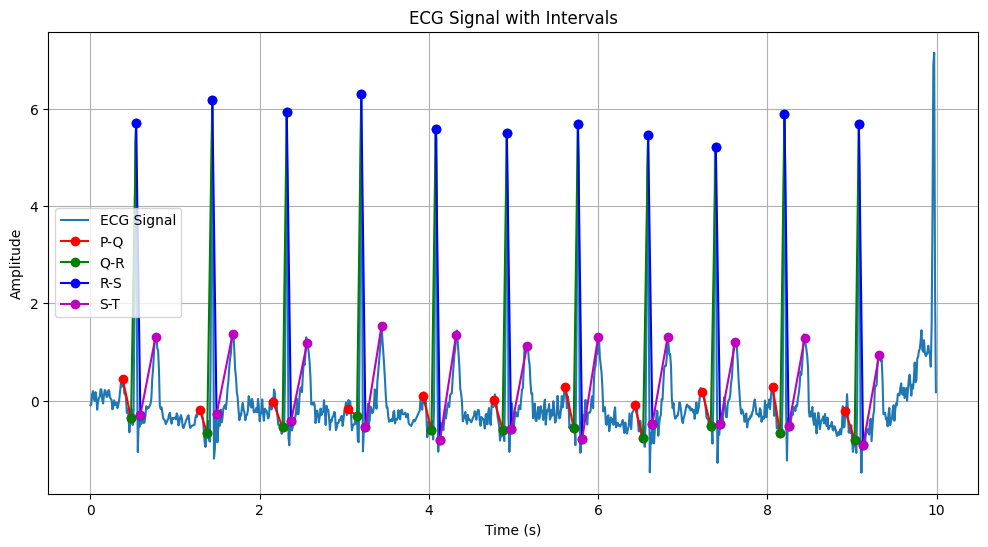

In [12]:
ecg = X_test[:, :, :]

classes = 0
indices = np.where(y_test[:, classes] == 1.0)[0]
index = np.random.choice(indices)
fs = 100
ecg_choose = ecg[index, :, :]
ecg_leadII = ecg_choose[:, 1]
r_peaks, _, _, _ = detect_r_peaks(ecg_leadII, fs)
ecg_choose = np.expand_dims(ecg_choose, axis=0)
waves, intervals = detect_pqst_slope(ecg_leadII, r_peaks, fs)
segments,np_segments = segment_PR_QRS_ST_QT(ecg_choose, waves)
plot_intervals(ecg_leadII, waves, fs)

PR: (12, 11, 50)
132


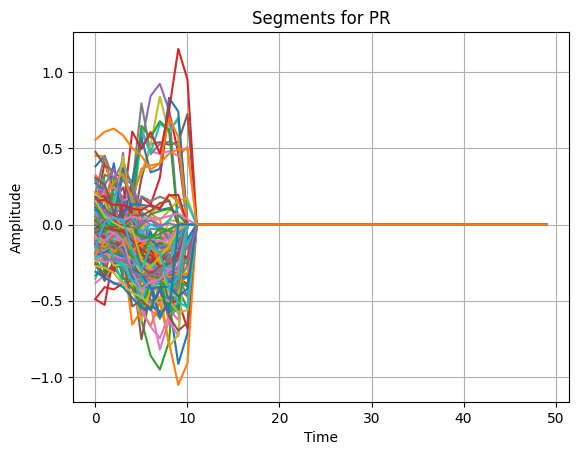

QRS: (12, 11, 50)
132


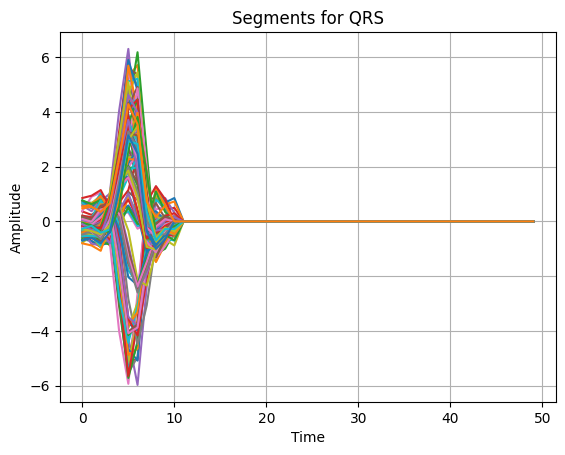

ST: (12, 11, 50)
132


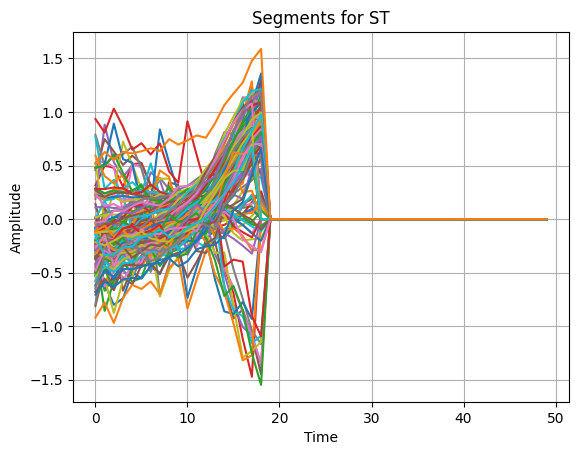

QT: (12, 11, 50)
132


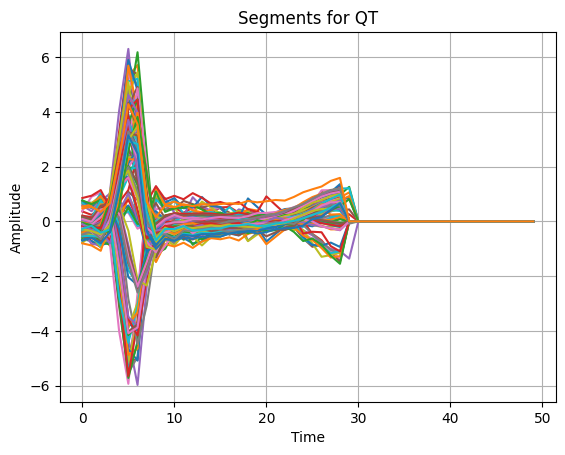

In [13]:
for i, k in enumerate(segments.keys()):
    count = 0
    print(f"{k}: {segments[k].shape}")
    for j in range(segments[k].shape[0]):
        for h in range(segments[k].shape[1]):
            count = count + 1
            plt.plot(segments[k][j, h, :])
    print(count)
    plt.title(f"Segments for {k}")
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()

In [15]:
#lead_indices = [0, 1, 6, 7, 8, 9, 10, 11]  # Assuming I=0, II=1, V1=6,...,V6=11
ecg = X_test[:, :, :]


# Example label_map and label_map_sub
label_map = {
    'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4
}

label_map_sub = {
    'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4,
    'CRBBB': 5, '_AVB': 6, 'WPW': 7, 'LVH': 8, 'LAO/LAE': 9, 
    'RAO/RAE': 10, 'AMI': 11, 'IMI': 12, 'LMI': 13, 'ISCA': 14, 
    'ISCI': 15, 'ISC_': 16, 'STTC': 17, 'NST_': 18
}


In [16]:
classes = 0

In [18]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

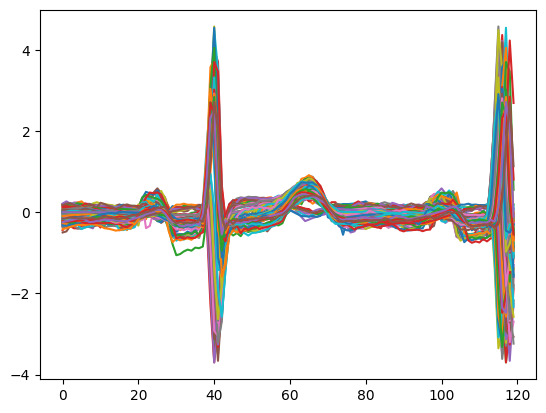

In [19]:
indices = np.where(y_test[:, classes] == 1.0)[0]
index = np.random.choice(indices)
fs = 100
ecg_choose = ecg[index, :, :]
ecg_leadII = ecg_choose[:, 1]
r_peaks, _, _, _ = detect_r_peaks(ecg_leadII, fs)
ecg_choose = np.expand_dims(ecg_choose, axis=0)
PQRST_segment = segment_PQRST(ecg_choose, r_peaks)

## PR-QRS-ST-QT segments
waves, intervals = detect_pqst_slope(ecg_leadII, r_peaks, fs)
segments,np_segments = segment_PR_QRS_ST_QT(ecg_choose, waves)

## Full PQRST segment
PQRST_segment_numpy = np.array(PQRST_segment)

PQRST_segment_numpy = PQRST_segment_numpy.transpose(1, 0, 2)
dower_matrix = np.array([
    [0.156, 0.037, -0.172],   # I
    [0.189, -0.310, -0.246],  # II
    [-0.097, 0.182, 0.231],   # V1
    [-0.072, 0.320, 0.136],   # V2
    [-0.189, 0.240, -0.141],  # V3
    [-0.114, 0.155, -0.073],  # V4
    [-0.022, 0.052, -0.018],  # V5
    [0.041, -0.062, -0.022],  # V6
])  # Shape: (8 leads, 3 VCG axes)

vcg = np.einsum('...lt,lc->...ct', PQRST_segment_numpy, dower_matrix)  # Result: (3, T)

In [ ]:
# print(PQRST_segment_numpy.shape[2])

140


In [ ]:
# print(intervals['Q'])
# print(intervals['R'])

[np.int64(34), np.int64(128), np.int64(220), np.int64(310), np.int64(399), np.int64(487), np.int64(575), np.int64(661), np.int64(751), np.int64(842), np.int64(933)]
[ 39 133 225 315 404 493 580 666 756 848 938]


In [ ]:
# print(intervals.keys())
# print(segments["PR"].shape)

dict_keys(['P', 'Q', 'R', 'S', 'T'])
(8, 14, 50)


In [ ]:
# print(len(waves))
# print("VCG shape:", vcg.shape)

14
VCG shape: (13, 3, 140)


In [21]:
# Function to convert original signal indices to beat segment indices
def convert_to_beat_index(intervals, beats, samples_per_beat, start_idx=40, end_idx=100):
    converted_intervals = {}
    duplicate_R = [i for i in intervals["R"]]
    for key, original_indices in intervals.items():
        converted_intervals[key] = []
        # For each beat, convert the original index to the corresponding beat index
        for i, original_idx in enumerate(original_indices):
            beat_idx = i % beats  # which beat this index belongs to
            if key == 'Q' or key == 'P' or key == 'R':
                # For Q and S, we need to adjust the index to be within the beat segment
                index_within_beat = intervals[key][i] - intervals['R'][i] + start_idx
            else:
                # For R, S, and T, we can directly use the index
                index_within_beat = intervals[key][i] - duplicate_R[i] + start_idx
            converted_intervals[key].append(index_within_beat)
            
    return converted_intervals

# Convert intervals
converted_intervals = convert_to_beat_index(intervals, PQRST_segment_numpy.shape[0], PQRST_segment_numpy.shape[2])
print("Original intervals:", intervals)
print("\n\n")
print("Converted intervals:", converted_intervals)

Original intervals: {'P': [np.int64(66), np.int64(163), np.int64(256), np.int64(348), np.int64(442), np.int64(536), np.int64(630), np.int64(722), np.int64(814), np.int64(908)], 'Q': [np.int64(76), np.int64(173), np.int64(265), np.int64(357), np.int64(451), np.int64(545), np.int64(640), np.int64(732), np.int64(824), np.int64(917)], 'R': array([ 81, 178, 271, 363, 457, 551, 645, 737, 829, 922]), 'S': [np.int64(86), np.int64(183), np.int64(276), np.int64(368), np.int64(462), np.int64(556), np.int64(650), np.int64(742), np.int64(834), np.int64(927)], 'T': [np.int64(110), np.int64(207), np.int64(299), np.int64(391), np.int64(486), np.int64(580), np.int64(674), np.int64(766), np.int64(858), np.int64(951)]}



Converted intervals: {'P': [np.int64(25), np.int64(25), np.int64(25), np.int64(25), np.int64(25), np.int64(25), np.int64(25), np.int64(25), np.int64(25), np.int64(26)], 'Q': [np.int64(35), np.int64(35), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(35), np.int64(35), 

In [ ]:
# print("PQRST_segment_numpy.shape:", PQRST_segment_numpy.shape)

PQRST_segment_numpy.shape: (13, 8, 140)


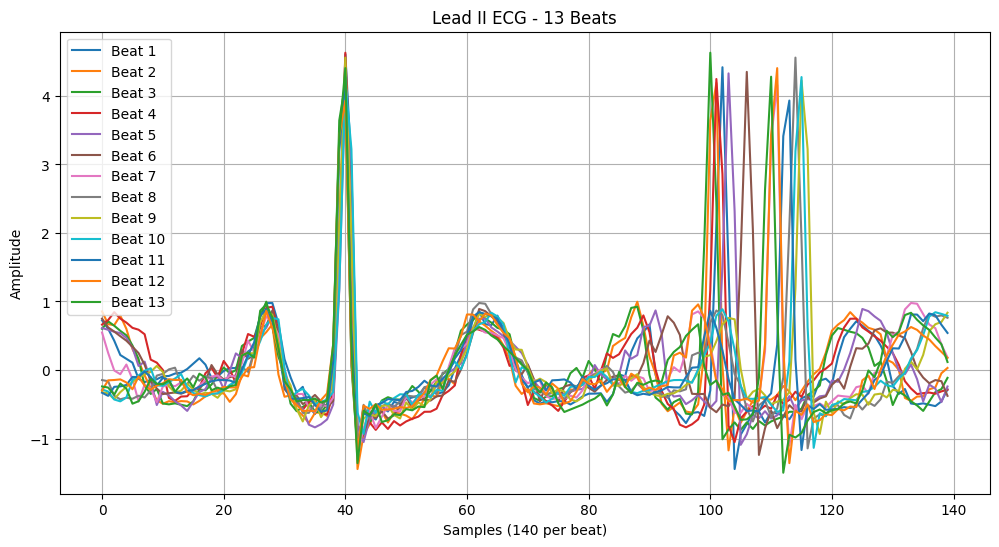

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Simulated PQRST_segment_numpy (replace with your actual data)
# # Shape: (13, 8, 140) -> 13 beats, 8 leads, 140 samples per beat

# # Extract Lead II (index 1)
# lead_ii_data = PQRST_segment_numpy[:, 1, :]  # Shape: (13, 140)

# # Plot Lead II across all 13 beats
# plt.figure(figsize=(12, 6))

# # Plot all 13 beats for Lead II
# for i in range(PQRST_segment_numpy.shape[0]):
#     plt.plot(np.arange(140), lead_ii_data[i], label=f"Beat {i+1}")

# plt.title("Lead II ECG - 13 Beats")
# plt.xlabel("Samples (140 per beat)")
# plt.ylabel("Amplitude")
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
# def plot_intervals(signal, intervals, fs):
#     plt.figure(figsize=(12, 6))
#     t = np.arange(len(signal)) / fs
#     plt.plot(t, signal, label='ECG Signal')

#     for interval in intervals:
#         r = interval['R'] / fs
#         p = interval['P'] / fs
#         q = interval['Q'] / fs
#         s = interval['S'] / fs
#         t_wave = interval['T'] / fs
        
#         plt.plot([p, q], [signal[interval['P']], signal[interval['Q']]], 'ro-')
#         plt.plot([q, r], [signal[interval['Q']], signal[interval['R']]], 'go-')
#         plt.plot([r, s], [signal[interval['R']], signal[interval['S']]], 'bo-')
#         plt.plot([s, t_wave], [signal[interval['S']], signal[interval['T']]], 'mo-')

#     plt.title('ECG Signal with Intervals')
#     plt.xlabel('Time (s)')
#     plt.ylabel('Amplitude')
#     plt.legend(['ECG Signal', 'P-Q', 'Q-R', 'R-S', 'S-T'])
#     plt.grid()
#     plt.show()

In [ ]:
# print(lead_ii_data.shape)

(13, 140)


In [16]:
i = 1
plt.figure(figsize=(12, 6))
lead_ii_data = PQRST_segment_numpy[:, 1, :]  # Shape: (13, 140)
signal = lead_ii_data[i]
fs = 100
t = np.arange(len(signal)) / fs
plt.plot(t, signal, label=f'ECG Signal Beat {i}')
r = converted_intervals['R'][i] / fs
p = converted_intervals['P'][i] / fs
q = converted_intervals['Q'][i] / fs
s = converted_intervals['S'][i] / fs
t_wave = converted_intervals['T'][i] / fs
plt.plot([p, q], [signal[converted_intervals['P'][i]], signal[converted_intervals['Q'][i]]], 'ro-')
plt.plot([q, r], [signal[converted_intervals['Q'][i]], signal[converted_intervals['R'][i]]], 'go-')
plt.plot([r, s], [signal[converted_intervals['R'][i]], signal[converted_intervals['S'][i]]], 'bo-')
plt.plot([s, t_wave], [signal[converted_intervals['S'][i]], signal[converted_intervals['T'][i]]], 'mo-')
plt.title('ECG Signal with Intervals')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(['ECG Signal', 'P-Q', 'Q-R', 'R-S', 'S-T'])
plt.grid()
plt.show()

NameError: name 'PQRST_segment_numpy' is not defined

<Figure size 1200x600 with 0 Axes>

In [17]:
lead_indices = [0, 1, 6, 7, 8, 9, 10, 11]  # Assuming I=0, II=1, V1=6,...,V6=11
ecg = X_test[:, :, :]

In [42]:
classes =  0
indices = np.where(y_test[:, classes] == 1.0)[0]
index = np.random.choice(indices)

In [30]:
# Inverse Dower (IDT) 3×12
dower_matrix = np.array([
    [ 0.156, -0.010, 0.0, 0.0, 0.0, 0.0, -0.172, -0.074,  0.122,  0.231,  0.239,  0.194],
    [-0.227,  0.887, 0.0, 0.0, 0.0, 0.0,  0.057, -0.019, -0.106, -0.022,  0.041,  0.048],
    [ 0.022,  0.102, 0.0, 0.0, 0.0, 0.0, -0.229, -0.310, -0.246, -0.063,  0.055,  0.108]
])

# Kors regression 3×12
kors_matrix = np.array([
    [ 0.380, -0.070, 0.0, 0.0, 0.0, 0.0, -0.130,  0.050, -0.010,  0.140,  0.060,  0.540],
    [-0.070,  0.930, 0.0, 0.0, 0.0, 0.0,  0.060, -0.020, -0.050,  0.060, -0.170,  0.130],
    [ 0.110, -0.230, 0.0, 0.0, 0.0, 0.0, -0.430, -0.060, -0.140, -0.200, -0.110,  0.310]
])

QRS Start: 35, QRS End: 45, T Start: 61, T End: 76, ST J-offset: 50
QRS Start: 34, QRS End: 44, T Start: 61, T End: 76, ST J-offset: 49
QRS Start: 34, QRS End: 44, T Start: 61, T End: 76, ST J-offset: 49
QRS Start: 35, QRS End: 45, T Start: 61, T End: 76, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 62, T End: 77, ST J-offset: 50
QRS Start: 34, QRS End: 45, T Start: 62, T End: 77, ST J-offset: 50
QRS Start: 34, QRS End: 45, T Start: 61, T End: 76, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 61, T End: 76, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 60, T End: 75, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 62, T End: 77, ST J-offset: 50


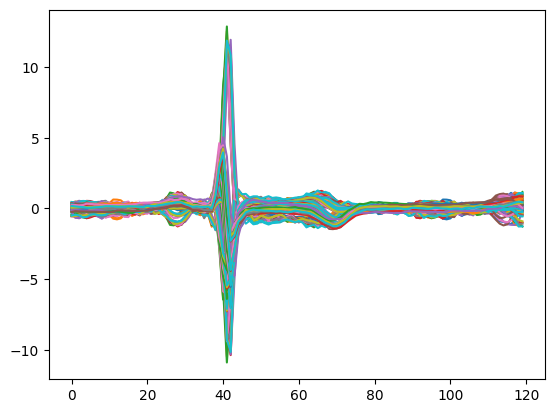

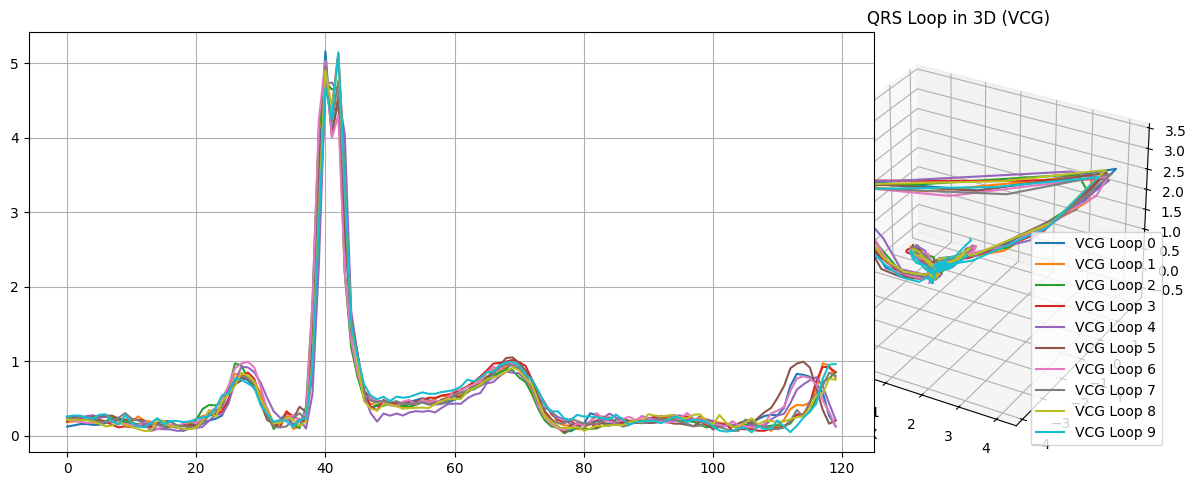

Supper Class: ['HYP', 'MI', 'STTC'], Sub Class: ['LAO/LAE', 'AMI', 'ISCA']
   QRS-T Spatial Angle (deg)  QRS Loop Planarity  QRS Duration (ms)  \
0                     137.85              0.5264              100.0   
1                     141.24              0.6882              100.0   
2                     138.20              0.7141              100.0   
3                     139.84              0.7238              100.0   
4                     140.09              0.6711              100.0   
5                     131.37              0.6019              110.0   
6                     142.62              0.5221              110.0   
7                     138.68              0.6179              100.0   
8                     141.96              0.6874              100.0   
9                     139.84              0.6783              100.0   

                  ST Vector  T-loop Polarity (relative to QRS)  \
0   [-0.19, -0.193, -0.348]                                 -1   
1  [-0.202,

In [40]:

fs = 100
ecg_choose = ecg[index, :, :]
ecg_leadII = ecg_choose[:, 1]
r_peaks, _, _, _ = detect_r_peaks(ecg_leadII, fs)
ecg_choose = np.expand_dims(ecg_choose, axis=0)
PQRST_segment = segment_PQRST(ecg_choose, r_peaks)


##

PQRST_segment_numpy = np.array(PQRST_segment)

## PR-QRS-ST-QT segments
waves, intervals = detect_pqst_slope(ecg_leadII, r_peaks, fs)
segments,np_segments = segment_PR_QRS_ST_QT(ecg_choose, waves)

converted_intervals = convert_to_beat_index(intervals, PQRST_segment_numpy.shape[0], PQRST_segment_numpy.shape[2])

##
PQRST_segment_numpy = PQRST_segment_numpy.transpose(1, 0, 2)


vcg = np.einsum('...lt,lc->...ct', PQRST_segment_numpy, dower_matrix.T)  # Result: (3, T)

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Initialize the dictionary to store results
results = []
fig = plt.figure(figsize=(24,12))
ax = fig.add_subplot(211, projection='3d')
ax2 = fig.add_subplot(221)
# Loop through each VCG instance (QRS complex)
for i in range(vcg.shape[0]):
    # Transpose and fit PCA
    vcg_transpose = vcg.transpose(0, 2, 1)[i]
    pca = PCA(n_components=3)
    pca.fit(vcg_transpose)
    explained_var = pca.explained_variance_ratio_  # array of shape (3,)
    components = pca.components_  # shape: (3, 3), each row = principal axis
    lam1, lam2, lam3 = pca.explained_variance_
    
    # Calculate Planarity, Nonplanarity, and Area
    planarity = lam2 / lam1
    nonplanarity = lam3 / lam1
    area = np.sqrt(lam1 * lam2)
    
    # Calculate QRS–T spatial angle
    qrs_start = converted_intervals['Q'][i]
    qrs_end = converted_intervals['S'][i]
    t_start = converted_intervals['T'][i] - 5
    t_end = converted_intervals['T'][i] + 10
    st_j_offset = converted_intervals['S'][i] + 5
    print(f"QRS Start: {qrs_start}, QRS End: {qrs_end}, T Start: {t_start}, T End: {t_end}, ST J-offset: {st_j_offset}")
    
    qrs_vec = vcg[i, :, qrs_start:qrs_end].mean(axis=1)
    t_vec = vcg[i, :, t_start:t_end].mean(axis=1)
    cos_theta = np.dot(qrs_vec, t_vec) / (np.linalg.norm(qrs_vec) * np.linalg.norm(t_vec))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # for numerical safety
    qrs_t_angle_deg = np.degrees(np.arccos(cos_theta))
    
    # QRS loop planarity via PCA
    qrs_loop = vcg[i, :, qrs_start:qrs_end].T  # shape (N, 3)
    pca = PCA(n_components=3).fit(qrs_loop)
    qrs_planarity = pca.explained_variance_[1] / pca.explained_variance_[0]
    
    # QRS duration (in ms)
    sampling_rate = 100  # Hz
    qrs_duration_ms = (qrs_end - qrs_start) * 1000 / sampling_rate
    
    # ST vector (J-point + 10 ms)
    st_vector = vcg[i, :, st_j_offset]
    
    # T-loop polarity (dot product sign between T and QRS vector)
    t_loop = vcg[i, :, t_start:t_end]
    t_pca = PCA(n_components=1).fit(t_loop.T)
    t_axis = t_pca.components_[0]
    t_polarity = np.sign(np.dot(t_axis, qrs_vec))
    
    # Store results in the dictionary
    result = {
        'QRS-T Spatial Angle (deg)': round(qrs_t_angle_deg, 2),
        'QRS Loop Planarity': round(qrs_planarity, 4),
        'QRS Duration (ms)': qrs_duration_ms,
        'ST Vector': np.round(st_vector, 3),
        'T-loop Polarity (relative to QRS)': int(t_polarity),
        'Explained Variance Ratio': explained_var.tolist(),
        'Area': area
    }
    
    # Append result for this QRS
    results.append(result)

    # Optional: Plot 3D VCG loop
    ax.plot(vcg_transpose[:, 0], vcg_transpose[:, 1], vcg_transpose[:, 2], label=f'VCG Loop {i}')
    vcg_magnitude = np.sqrt(vcg_transpose[:, 0]**2 + vcg_transpose[:, 1]**2 + vcg_transpose[:, 2]**2)
    ax2.plot(vcg_magnitude)
    
ax.set_title("QRS Loop in 3D (VCG)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
ax2.grid(True)
plt.show()
# Step 2: Convert results into a Pandas DataFrame
df = pd.DataFrame(results)
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Disable line wrapping
pd.set_option('display.max_colwidth', None)  # Display full column content
super_class_indices = np.where(y_test[index] == 1)[0]
super_class_labels = [label for label, idx in label_map.items() if idx in super_class_indices]

# Extract sub class labels (all indices where 1's appear)
sub_class_indices = np.where(z_test[index] == 1)[0]
sub_class_labels = [label for label, idx in label_map_sub.items() if idx in sub_class_indices]


# Print the DataFrame in a tabular manner
print(f"Supper Class: {super_class_labels}, Sub Class: {sub_class_labels}")
print(df)


QRS Start: 34, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 34, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 58, T End: 73, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 57, T End: 72, ST J-offset: 50
QRS Start: 34, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 35, QRS End: 45, T Start: 57, T End: 72, ST J-offset: 50
QRS Start: 34, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50
QRS Start: 34, QRS End: 45, T Start: 56, T End: 71, ST J-offset: 50


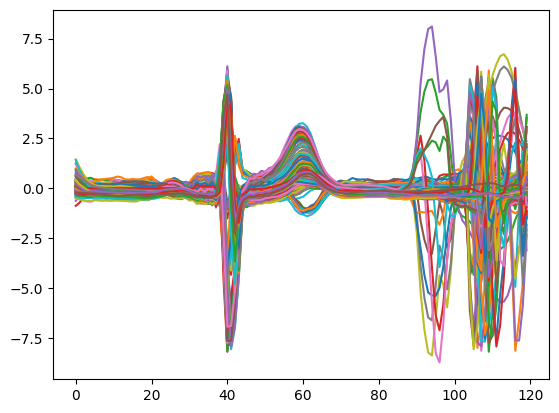

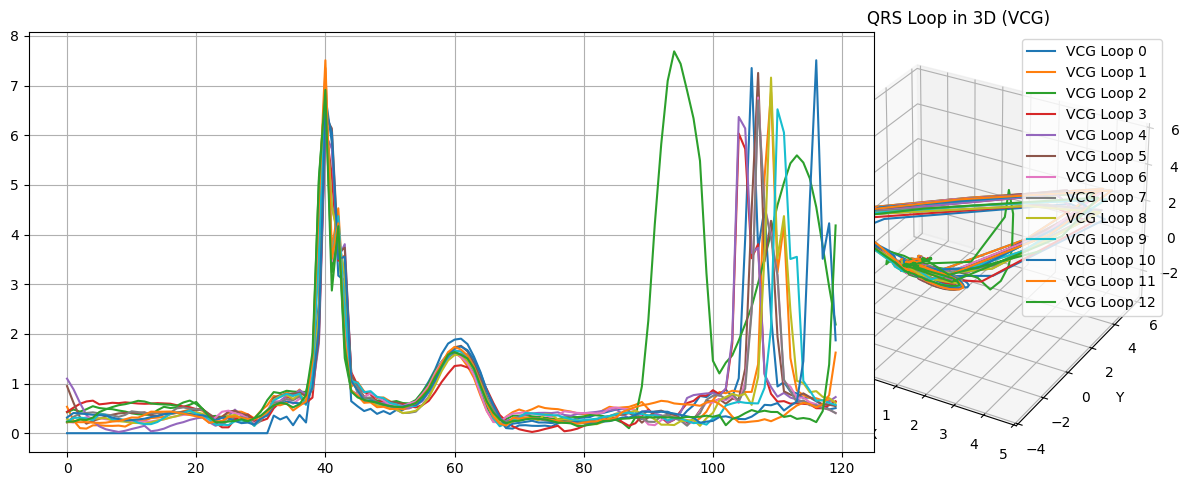

Supper Class: ['NORM'], Sub Class: ['NORM']
    QRS-T Spatial Angle (deg)  QRS Loop Planarity  QRS Duration (ms)  \
0                       69.21              0.2400              110.0   
1                      122.49              0.2326              100.0   
2                      123.87              0.2352              110.0   
3                       93.91              0.2000              100.0   
4                      121.38              0.2355              100.0   
5                      114.22              0.2371              100.0   
6                      117.56              0.2409              110.0   
7                      104.60              0.2251              100.0   
8                      105.90              0.2094              100.0   
9                      111.80              0.2201              100.0   
10                     101.11              0.2279              100.0   
11                     107.06              0.2306              110.0   
12                  

In [44]:

fs = 100
ecg_choose = ecg[index, :, :]
ecg_leadII = ecg_choose[:, 1]
r_peaks, _, _, _ = detect_r_peaks(ecg_leadII, fs)
ecg_choose = np.expand_dims(ecg_choose, axis=0)
PQRST_segment = segment_PQRST(ecg_choose, r_peaks)


##

PQRST_segment_numpy = np.array(PQRST_segment)

## PR-QRS-ST-QT segments
waves, intervals = detect_pqst_slope(ecg_leadII, r_peaks, fs)
segments,np_segments = segment_PR_QRS_ST_QT(ecg_choose, waves)

converted_intervals = convert_to_beat_index(intervals, PQRST_segment_numpy.shape[0], PQRST_segment_numpy.shape[2])

##
PQRST_segment_numpy = PQRST_segment_numpy.transpose(1, 0, 2)


vcg = np.einsum('...lt,lc->...ct', PQRST_segment_numpy, kors_matrix.T)  # Result: (3, T)

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Initialize the dictionary to store results
results = []
fig = plt.figure(figsize=(24,12))
ax = fig.add_subplot(211, projection='3d')
ax2 = fig.add_subplot(221)
# Loop through each VCG instance (QRS complex)
for i in range(vcg.shape[0]):
    # Transpose and fit PCA
    vcg_transpose = vcg.transpose(0, 2, 1)[i]
    pca = PCA(n_components=3)
    pca.fit(vcg_transpose)
    explained_var = pca.explained_variance_ratio_  # array of shape (3,)
    components = pca.components_  # shape: (3, 3), each row = principal axis
    lam1, lam2, lam3 = pca.explained_variance_
    
    # Calculate Planarity, Nonplanarity, and Area
    planarity = lam2 / lam1
    nonplanarity = lam3 / lam1
    area = np.sqrt(lam1 * lam2)
    
    # Calculate QRS–T spatial angle
    qrs_start = converted_intervals['Q'][i]
    qrs_end = converted_intervals['S'][i]
    t_start = converted_intervals['T'][i] - 5
    t_end = converted_intervals['T'][i] + 10
    st_j_offset = converted_intervals['S'][i] + 5
    print(f"QRS Start: {qrs_start}, QRS End: {qrs_end}, T Start: {t_start}, T End: {t_end}, ST J-offset: {st_j_offset}")
    
    qrs_vec = vcg[i, :, qrs_start:qrs_end].mean(axis=1)
    t_vec = vcg[i, :, t_start:t_end].mean(axis=1)
    cos_theta = np.dot(qrs_vec, t_vec) / (np.linalg.norm(qrs_vec) * np.linalg.norm(t_vec))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # for numerical safety
    qrs_t_angle_deg = np.degrees(np.arccos(cos_theta))
    
    # QRS loop planarity via PCA
    qrs_loop = vcg[i, :, qrs_start:qrs_end].T  # shape (N, 3)
    pca = PCA(n_components=3).fit(qrs_loop)
    qrs_planarity = pca.explained_variance_[1] / pca.explained_variance_[0]
    
    # QRS duration (in ms)
    sampling_rate = 100  # Hz
    qrs_duration_ms = (qrs_end - qrs_start) * 1000 / sampling_rate
    
    # ST vector (J-point + 10 ms)
    st_vector = vcg[i, :, st_j_offset]
    
    # T-loop polarity (dot product sign between T and QRS vector)
    t_loop = vcg[i, :, t_start:t_end]
    t_pca = PCA(n_components=1).fit(t_loop.T)
    t_axis = t_pca.components_[0]
    t_polarity = np.sign(np.dot(t_axis, qrs_vec))
    
    # Store results in the dictionary
    result = {
        'QRS-T Spatial Angle (deg)': round(qrs_t_angle_deg, 2),
        'QRS Loop Planarity': round(qrs_planarity, 4),
        'QRS Duration (ms)': qrs_duration_ms,
        'ST Vector': np.round(st_vector, 3),
        'T-loop Polarity (relative to QRS)': int(t_polarity),
        'Explained Variance Ratio': explained_var.tolist(),
        'Area': area
    }
    
    # Append result for this QRS
    results.append(result)

    # Optional: Plot 3D VCG loop
    ax.plot(vcg_transpose[:, 0], vcg_transpose[:, 1], vcg_transpose[:, 2], label=f'VCG Loop {i}')
    vcg_magnitude = np.sqrt(vcg_transpose[:, 0]**2 + vcg_transpose[:, 1]**2 + vcg_transpose[:, 2]**2)
    ax2.plot(vcg_magnitude)
    
ax.set_title("QRS Loop in 3D (VCG)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
ax2.grid(True)
plt.show()
# Step 2: Convert results into a Pandas DataFrame
df = pd.DataFrame(results)
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Disable line wrapping
pd.set_option('display.max_colwidth', None)  # Display full column content
super_class_indices = np.where(y_test[index] == 1)[0]
super_class_labels = [label for label, idx in label_map.items() if idx in super_class_indices]

# Extract sub class labels (all indices where 1's appear)
sub_class_indices = np.where(z_test[index] == 1)[0]
sub_class_labels = [label for label, idx in label_map_sub.items() if idx in sub_class_indices]


# Print the DataFrame in a tabular manner
print(f"Supper Class: {super_class_labels}, Sub Class: {sub_class_labels}")
print(df)
